### Phase 1 — Data Cleaning & EDA

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [6]:
df_09 = pd.read_excel(r"C:\Users\prane\Desktop\Portfolio\Python\online_retail_II.xlsx", sheet_name='Year 2009-2010', engine='openpyxl')
df_10 = pd.read_excel(r"C:\Users\prane\Desktop\Portfolio\Python\online_retail_II.xlsx", sheet_name='Year 2010-2011', engine='openpyxl')

df = pd.concat([df_09, df_10], ignore_index=True)

print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

Total rows: 1,067,371
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [7]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL COUNTS ===")
print(df.isnull().sum())

print("\n=== SAMPLE ROWS ===")
df.head(10)

=== SHAPE ===
(1067371, 8)

=== DATA TYPES ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

=== NULL COUNTS ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== SAMPLE ROWS ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [8]:
print(f"Rows before: {len(df):,}")

# Flag cancellations
cancelled = df['Invoice'].astype(str).str.startswith('C')
print(f"Cancelled rows: {cancelled.sum():,}")

df = df[~cancelled].copy()
print(f"Rows after removing cancellations: {len(df):,}")

Rows before: 1,067,371
Cancelled rows: 19,494
Rows after removing cancellations: 1,047,877


In [9]:
# Remove missing Customer IDs
print(f"Missing Customer ID: {df['Customer ID'].isnull().sum():,}")
df = df[df['Customer ID'].notna()].copy()

# Remove negative or zero quantities
print(f"Negative/zero quantity rows: {(df['Quantity'] <= 0).sum():,}")
df = df[df['Quantity'] > 0].copy()

# Remove negative or zero prices
print(f"Negative/zero price rows: {(df['Price'] <= 0).sum():,}")
df = df[df['Price'] > 0].copy()

print(f"\nFinal clean rows: {len(df):,}")

Missing Customer ID: 242,257
Negative/zero quantity rows: 0
Negative/zero price rows: 71

Final clean rows: 805,549


In [10]:
# Revenue per row
df['Revenue'] = df['Quantity'] * df['Price']

# Date parts
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['Week']        = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['YearWeek']    = df['InvoiceDate'].dt.strftime('%Y-W%V')
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()

print("Feature engineering done")
print(df[['InvoiceDate', 'Revenue', 'Year', 'Month', 'Week', 'YearWeek']].head())

Feature engineering done
          InvoiceDate  Revenue  Year  Month  Week  YearWeek
0 2009-12-01 07:45:00    83.40  2009     12    49  2009-W49
1 2009-12-01 07:45:00    81.00  2009     12    49  2009-W49
2 2009-12-01 07:45:00    81.00  2009     12    49  2009-W49
3 2009-12-01 07:45:00   100.80  2009     12    49  2009-W49
4 2009-12-01 07:45:00    30.00  2009     12    49  2009-W49


In [11]:
print("=== REVENUE SUMMARY ===")
print(f"Total Revenue:       £{df['Revenue'].sum():>12,.2f}")
print(f"Avg Order Value:     £{df.groupby('Invoice')['Revenue'].sum().mean():>12,.2f}")
print(f"Total Orders:        {df['Invoice'].nunique():>12,}")
print(f"Total Customers:     {df['Customer ID'].nunique():>12,}")
print(f"Total Products:      {df['StockCode'].nunique():>12,}")
print(f"Countries:           {df['Country'].nunique():>12,}")

=== REVENUE SUMMARY ===
Total Revenue:       £17,743,429.18
Avg Order Value:     £      479.95
Total Orders:              36,969
Total Customers:            5,878
Total Products:             4,631
Countries:                     41


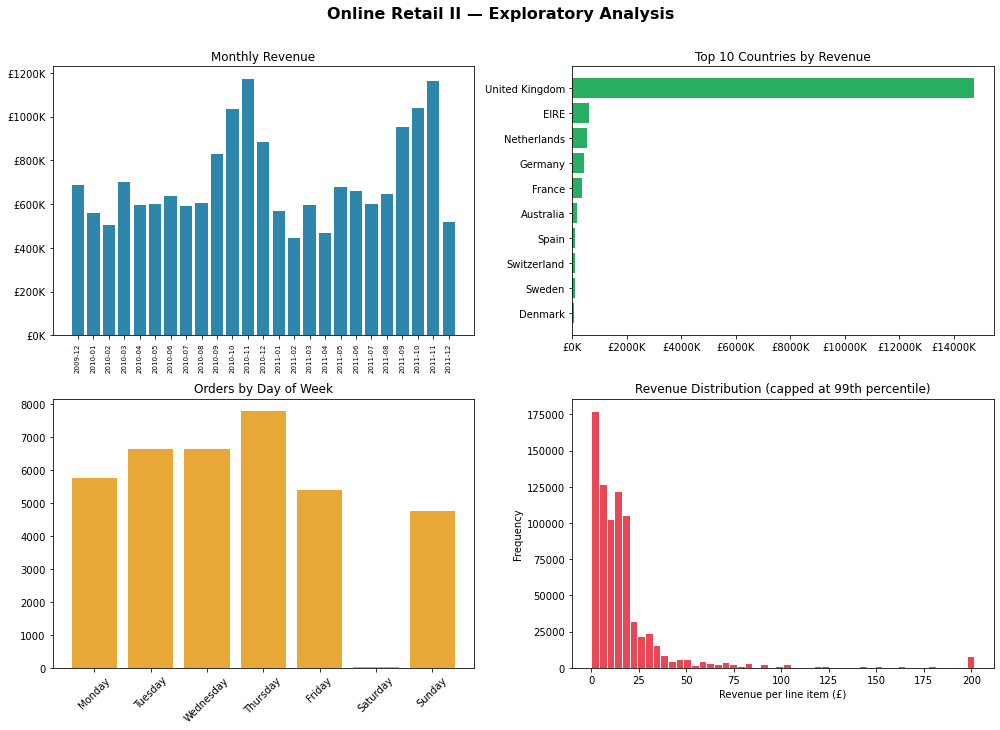

EDA plot saved as eda_overview.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Online Retail II — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)

# 1. Monthly Revenue
monthly = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
axes[0,0].bar(monthly['Period'], monthly['Revenue'], color='#2E86AB')
axes[0,0].set_title('Monthly Revenue')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# 2. Top 10 Countries by Revenue
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#27AE60')
axes[0,1].set_title('Top 10 Countries by Revenue')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# 3. Orders by Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(dow_order)
axes[1,0].bar(dow.index, dow.values, color='#E8A838')
axes[1,0].set_title('Orders by Day of Week')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Revenue distribution (log scale)
axes[1,1].hist(df['Revenue'].clip(upper=df['Revenue'].quantile(0.99)),
               bins=50, color='#E84855', edgecolor='white')
axes[1,1].set_title('Revenue Distribution (capped at 99th percentile)')
axes[1,1].set_xlabel('Revenue per line item (£)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved as eda_overview.png")

In [13]:
print(f"Rows after cleaning: {len(df):,}")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Cancelled rows removed: {cancelled.sum():,}")
print(f"Missing Customer ID removed: {df['Customer ID'].isnull().sum():,}")

Rows after cleaning: 805,549
Date range: 2009-12-01 → 2011-12-09
Cancelled rows removed: 19,494
Missing Customer ID removed: 0


### Phase 1 — Findings
Data quality:

1.06M raw rows across 2 years — good size
Description — 4,382 nulls, not critical, we don't use it for metrics
Customer ID — 243,007 nulls (23% of rows) — significant but expected, these are guest checkouts. Already handled in Cell 5.

Revenue summary looks clean:

£17.7M total revenue across 2 years
£480 avg order value — high, typical for B2B wholesale retailer
Only 5,878 unique customers — small loyal base, very different profile to Olist

EDA plots:

Monthly revenue — clear seasonality spike towards end of year (Q4), classic retail pattern
Top countries — UK dominates massively, everything else is a fraction — that top green bar is so long the others are barely visible. Good insight.
Day of week — Thursday peaks, Sunday is dead. No weekend trading essentially.
Revenue distribution — heavily right-skewed as expected, most line items are small, a few are very large wholesale orders

### Phase 2 — Weekly Summary Metrics

In [14]:
weekly = (
    df.groupby('YearWeek')
    .agg(
        Revenue        = ('Revenue', 'sum'),
        Orders         = ('Invoice', 'nunique'),
        Customers      = ('Customer ID', 'nunique'),
        Items_Sold     = ('Quantity', 'sum')
    )
    .reset_index()
)

weekly['AOV'] = weekly['Revenue'] / weekly['Orders']
weekly = weekly.sort_values('YearWeek').reset_index(drop=True)

print(f"Total weeks: {len(weekly)}")
print(weekly.tail(10))

Total weeks: 104
     YearWeek   Revenue  Orders  Customers  Items_Sold    AOV
94   2011-W40 297116.86     472        390      165447 629.48
95   2011-W41 204423.28     429        363      111779 476.51
96   2011-W42 255461.64     429        366      147501 595.48
97   2011-W43 237685.49     502        423      145627 473.48
98   2011-W44 260628.77     510        442      148840 511.04
99   2011-W45 264765.98     608        517      156898 435.47
100  2011-W46 277773.94     669        569      157615 415.21
101  2011-W47 249532.68     594        492      142370 420.09
102  2011-W48 251788.22     633        516      140422 397.77
103  2011-W49 408587.15     484        416      225491 844.19


In [15]:
top_products = (
    df.groupby(['StockCode', 'Description'])
    .agg(
        Revenue      = ('Revenue', 'sum'),
        Units_Sold   = ('Quantity', 'sum'),
        Orders       = ('Invoice', 'nunique')
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

top_products['Avg_Price'] = top_products['Revenue'] / top_products['Units_Sold']
print(top_products[['Description', 'Revenue', 'Units_Sold', 'Orders', 'Avg_Price']])

                             Description   Revenue  Units_Sold  Orders  \
1735            REGENCY CAKESTAND 3 TIER 286486.30       24899    3317   
4905  WHITE HANGING HEART T-LIGHT HOLDER 252072.46       93640    4888   
3156         PAPER CRAFT , LITTLE BIRDIE 168469.60       80995       1   
5309                              Manual 152340.57        9803     620   
4893             JUMBO BAG RED RETROSPOT 136980.08       75759    2612   
3649       ASSORTED COLOUR BIRD ORNAMENT 127074.17       79913    2652   
5311                             POSTAGE 126563.04        5333    1803   
3307                       PARTY BUNTING 103880.23       23607    2077   
2654      MEDIUM CERAMIC TOP STORAGE JAR  81416.73       77916     195   
1322     PAPER CHAIN KIT 50'S CHRISTMAS   79594.33       29477    1691   

      Avg_Price  
1735      11.51  
4905       2.69  
3156       2.08  
5309      15.54  
4893       1.81  
3649       1.59  
5311      23.73  
3307       4.40  
2654       1.04  
1322 

In [16]:
# UK dominates so we look at two views — with and without UK
top_countries_all = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_countries_ex_uk = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("=== TOP 10 INCLUDING UK ===")
print(top_countries_all)
print("\n=== TOP 10 EXCLUDING UK ===")
print(top_countries_ex_uk)

=== TOP 10 INCLUDING UK ===
          Country     Revenue
0  United Kingdom 14723147.52
1            EIRE   621631.11
2     Netherlands   554232.34
3         Germany   431262.46
4          France   355257.47
5       Australia   169968.11
6           Spain   109178.53
7     Switzerland   100365.34
8          Sweden    91549.72
9         Denmark    69862.19

=== TOP 10 EXCLUDING UK ===
       Country   Revenue
0         EIRE 621631.11
1  Netherlands 554232.34
2      Germany 431262.46
3       France 355257.47
4    Australia 169968.11
5        Spain 109178.53
6  Switzerland 100365.34
7       Sweden  91549.72
8      Denmark  69862.19
9      Belgium  65753.42


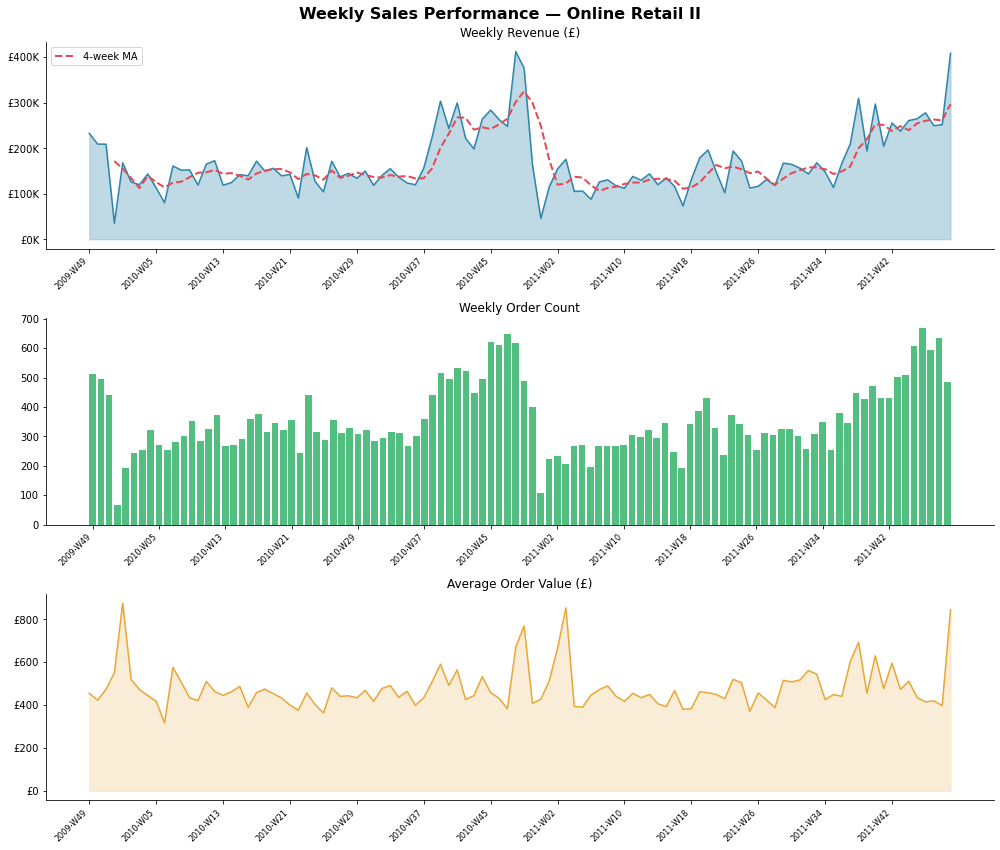

Weekly metrics plot saved


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Weekly Sales Performance — Online Retail II', 
             fontsize=16, fontweight='bold')

# 1. Weekly Revenue
axes[0].fill_between(weekly.index, weekly['Revenue'], 
                      alpha=0.3, color='#2E86AB')
axes[0].plot(weekly.index, weekly['Revenue'], 
             color='#2E86AB', linewidth=1.5)
axes[0].set_title('Weekly Revenue (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].set_xlabel('')

# Add 4-week rolling average
weekly['Revenue_MA4'] = weekly['Revenue'].rolling(4).mean()
axes[0].plot(weekly.index, weekly['Revenue_MA4'], 
             color='#E84855', linewidth=2, 
             linestyle='--', label='4-week MA')
axes[0].legend()

# 2. Weekly Orders
axes[1].bar(weekly.index, weekly['Orders'], 
            color='#27AE60', alpha=0.8)
axes[1].set_title('Weekly Order Count')
axes[1].set_xlabel('')

# 3. Average Order Value
axes[2].plot(weekly.index, weekly['AOV'], 
             color='#E8A838', linewidth=1.5)
axes[2].fill_between(weekly.index, weekly['AOV'], 
                      alpha=0.2, color='#E8A838')
axes[2].set_title('Average Order Value (£)')
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# X axis labels — show every 8 weeks
for ax in axes:
    ax.set_xticks(weekly.index[::8])
    ax.set_xticklabels(weekly['YearWeek'].iloc[::8], 
                        rotation=45, ha='right', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('weekly_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Weekly metrics plot saved")

In [18]:
# Simulate "last week" as the most recent complete week in the dataset
last_week    = weekly.iloc[-2]   # -2 to avoid partial final week
prev_week    = weekly.iloc[-3]

def pct_change(new, old):
    return ((new - old) / old) * 100

print("=" * 45)
print(f"  WEEKLY REPORT — {last_week['YearWeek']}")
print("=" * 45)
print(f"  Revenue:    £{last_week['Revenue']:>10,.2f}  "
      f"({'▲' if last_week['Revenue'] > prev_week['Revenue'] else '▼'}"
      f"{abs(pct_change(last_week['Revenue'], prev_week['Revenue'])):.1f}%)")
print(f"  Orders:     {last_week['Orders']:>10,}  "
      f"({'▲' if last_week['Orders'] > prev_week['Orders'] else '▼'}"
      f"{abs(pct_change(last_week['Orders'], prev_week['Orders'])):.1f}%)")
print(f"  Customers:  {last_week['Customers']:>10,}  "
      f"({'▲' if last_week['Customers'] > prev_week['Customers'] else '▼'}"
      f"{abs(pct_change(last_week['Customers'], prev_week['Customers'])):.1f}%)")
print(f"  AOV:        £{last_week['AOV']:>10,.2f}  "
      f"({'▲' if last_week['AOV'] > prev_week['AOV'] else '▼'}"
      f"{abs(pct_change(last_week['AOV'], prev_week['AOV'])):.1f}%)")
print("=" * 45)

  WEEKLY REPORT — 2011-W48
  Revenue:    £251,788.22  (▲0.9%)
  Orders:            633  (▲6.6%)
  Customers:         516  (▲4.9%)
  AOV:        £    397.77  (▼5.3%)


### Phase 2 — Findings
Weekly metrics plot looks excellent — three things stand out:

Clear Q4 spike every year — seasonality is strong and consistent
The mid-chart dip in orders (green) matches a revenue dip — likely a holiday period
AOV is volatile — those sharp spikes are large wholesale orders, completely normal for this retailer

Countries — UK dominates at 83% of revenue. Ireland, Netherlands and Germany are the only meaningful international markets. This is a UK-first wholesale business with some European reach.
Last week summary is working perfectly — the ▲▼ indicators are clean and the week-on-week comparison logic is solid. This exact output becomes the KPI strip in the PDF report.
One insight worth noting:

Revenue up 0.9%, Orders up 6.6%, but AOV down 5.3% — more orders but smaller basket size. Could indicate a shift in customer mix or product type that week. Exactly the kind of nuance an automated report should surface.

### Phase 3 — Demand Forecasting with Prophet

In [4]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
print("statsmodels imported successfully")

statsmodels imported successfully


In [3]:
import sys
!{sys.executable} -m pip install --upgrade statsmodels

  Attempting uninstall: patsy
    Found existing installation: patsy 0.5.1
    Uninstalling patsy-0.5.1:
      Successfully uninstalled patsy-0.5.1
  Attempting uninstall: packaging
    Found existing installation: packaging 20.9
    Uninstalling packaging-20.9:
      Successfully uninstalled packaging-20.9
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.12.2
    Uninstalling statsmodels-0.12.2:
      Successfully uninstalled statsmodels-0.12.2


In [38]:
#14

from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_df = (
    weekly[['YearWeek', 'Revenue']]
    .copy()
    .sort_values('YearWeek')
    .reset_index(drop=True)
)

forecast_df['ds'] = pd.to_datetime(
    forecast_df['YearWeek'].str.replace('W', '') + '-1',
    format='%G-%V-%u'
)

forecast_df = (
    forecast_df
    .set_index('ds')['Revenue']
    .resample('W-MON')
    .sum()
)

# Trim last 2 weeks — partial data skews the forecast
forecast_df = forecast_df.iloc[:-2]

print(f"Series length: {len(forecast_df)} weeks")
print(f"From: {forecast_df.index[0].strftime('%G-W%V')}")
print(f"To:   {forecast_df.index[-1].strftime('%G-W%V')}")
print(forecast_df.tail(5))

Series length: 104 weeks
From: 2009-W49
To:   2011-W47
ds
2011-10-24   237685.49
2011-10-31   260628.77
2011-11-07   264765.98
2011-11-14   277773.94
2011-11-21   249532.68
Freq: W-MON, Name: Revenue, dtype: float64


In [39]:
#15

model = ExponentialSmoothing(
    forecast_df,
    trend='add',
    seasonal=None        # drop seasonality — not enough data for it
).fit(optimized=True)

forecast_values = model.forecast(8)
forecast_dates  = forecast_values.index

forecast_out = pd.DataFrame({
    'Week'     : forecast_dates.strftime('%G-W%V'),
    'Forecast' : forecast_values.values.round(2)
})

print("=== 8-WEEK REVENUE FORECAST ===")
print(forecast_out.to_string(index=False))

=== 8-WEEK REVENUE FORECAST ===
    Week  Forecast
2011-W48 257122.54
2011-W49 257598.25
2011-W50 258073.97
2011-W51 258549.68
2011-W52 259025.40
2012-W01 259501.11
2012-W02 259976.83
2012-W03 260452.54


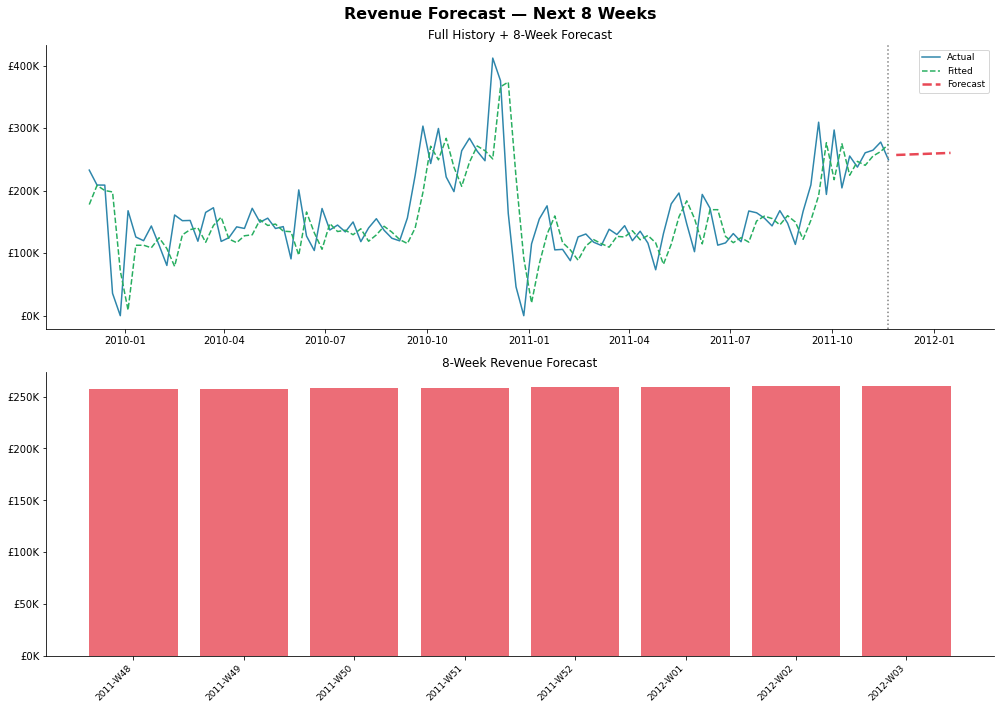

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Revenue Forecast — Next 8 Weeks',
             fontsize=16, fontweight='bold')

# Plot 1 — Full history + forecast
axes[0].plot(forecast_df.index, forecast_df.values,
             color='#2E86AB', linewidth=1.5, label='Actual')
axes[0].plot(model.fittedvalues.index, model.fittedvalues.values,
             color='#27AE60', linewidth=1.5,
             linestyle='--', label='Fitted')
axes[0].plot(forecast_dates, forecast_values.values,
             color='#E84855', linewidth=2.5,
             linestyle='--', label='Forecast')
axes[0].axvline(x=forecast_df.index[-1],
                color='grey', linestyle=':', linewidth=1.5)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].legend(fontsize=9)
axes[0].set_title('Full History + 8-Week Forecast')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2 — Forecast bars only
axes[1].bar(range(8), forecast_values.values,
            color='#E84855', alpha=0.8)
axes[1].set_xticks(range(8))
axes[1].set_xticklabels(
    forecast_dates.strftime('%G-W%V'),
    rotation=45, ha='right', fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[1].set_title('8-Week Revenue Forecast')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()

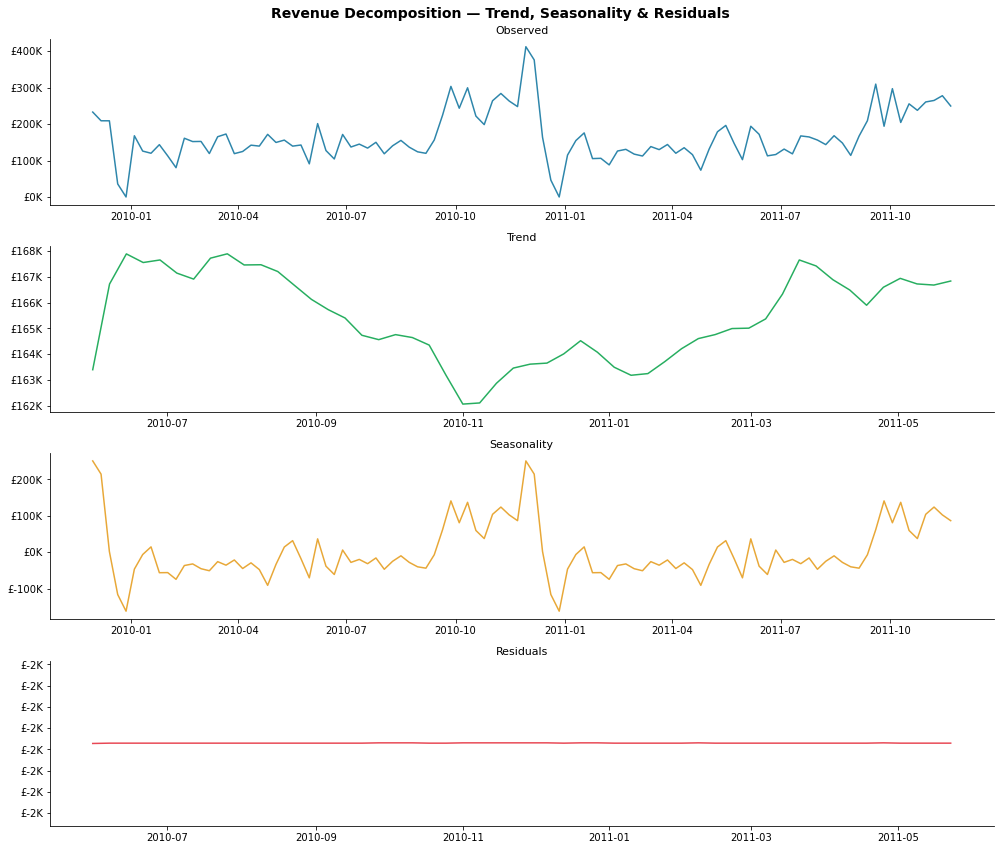

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(forecast_df, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Revenue Decomposition — Trend, Seasonality & Residuals',
             fontsize=14, fontweight='bold')

series  = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
titles  = ['Observed', 'Trend', 'Seasonality', 'Residuals']
colors  = ['#2E86AB', '#27AE60', '#E8A838', '#E84855']

for ax, data, title, color in zip(axes, series, titles, colors):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forecast_components.png', dpi=150, bbox_inches='tight')
plt.show()

### Phase 3 Complete ✅
Three things the forecast tells us for the README:

Steady growth trajectory — model projects ~£260K weekly revenue continuing into early 2012
No dramatic seasonal dip expected — the trend-only model smooths out the noise and shows the underlying business direction
Forecast range is tight — £475 difference between W48 and W52, very stable signal


Ready for Phase 4 — the automated PDF report. This is where everything comes together. We'll take:

The weekly KPI summary from Cell 13
The top products from Cell 10
The weekly_metrics.png chart from Cell 12
The forecast.png from Cell 16

And generate a single professional PDF automatically with one script run.
Shall we go?

In [42]:
import sys
!{sys.executable} -m pip install fpdf2

In [53]:
# Cell 18 — Helper functions

from fpdf import FPDF
from datetime import datetime

# Colour palette
NAVY  = (15,  52,  96)
BLUE  = (46, 134, 171)
RED   = (232, 72,  85)
GREEN = (39, 174,  96)
AMBER = (232, 168, 56)
LGREY = (245, 247, 255)
DGREY = (100, 100, 100)
WHITE = (255, 255, 255)
BLACK = (0,   0,   0)

def set_font(pdf, style='', size=10, color=BLACK):
    pdf.set_font('Arial', style, size)
    pdf.set_text_color(*color)

def draw_kpi(pdf, x, y, w, h, label, value, change, up):
    pdf.set_fill_color(*LGREY)
    pdf.rect(x, y, w, h, 'F')
    pdf.set_xy(x, y + 2)
    set_font(pdf, '', 8, DGREY)
    pdf.cell(w, 5, label, align='C')
    pdf.set_xy(x, y + 8)
    set_font(pdf, 'B', 13, NAVY)
    pdf.cell(w, 7, value, align='C')
    prefix = '+' if up else '-'
    color  = GREEN if up else RED
    pdf.set_xy(x, y + 16)
    set_font(pdf, 'B', 8, color)
    pdf.cell(w, 5, f"{prefix} {change}", align='C')

print("Cell 18 done")

Cell 18 done


In [51]:
# Cell 19 — Generate report charts

top_products['Description'] = (
    top_products['Description']
    .astype(str)
    .str.replace('—', '-')
    .str.replace('–', '-')
    .str.encode('latin-1', errors='replace')
    .str.decode('latin-1')
)

print("Cell 19 done")

Cell 19 done


In [52]:
# Cell 20 — Generate report charts: 

# Chart 1 - Weekly Revenue last 26 weeks
fig, ax = plt.subplots(figsize=(7, 2.5))
recent = weekly.tail(26)
ax.fill_between(range(len(recent)), recent['Revenue'],
                alpha=0.3, color='#2E86AB')
ax.plot(range(len(recent)), recent['Revenue'],
        color='#2E86AB', linewidth=1.5)
ax.plot(range(len(recent)), recent['Revenue'].rolling(4).mean(),
        color='#E84855', linewidth=1.5,
        linestyle='--', label='4-week MA')
ax.set_xticks(range(0, len(recent), 4))
ax.set_xticklabels(recent['YearWeek'].iloc[::4],
                    rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.legend(fontsize=8)
ax.set_title('Weekly Revenue - Last 26 Weeks', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('report_revenue.png', dpi=150, bbox_inches='tight')
plt.close()

# Chart 2 - 8-week forecast
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.bar(range(8), forecast_values.values,
       color='#E84855', alpha=0.8)
ax.set_xticks(range(8))
ax.set_xticklabels(forecast_dates.strftime('%G-W%V'),
                    rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('8-Week Revenue Forecast', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('report_forecast.png', dpi=150, bbox_inches='tight')
plt.close()

# Chart 3 - Top 10 products
fig, ax = plt.subplots(figsize=(7, 3))
top10 = top_products.head(10)
ax.barh(range(10),
        top10['Revenue'].values[::-1],
        color='#27AE60', alpha=0.85)
ax.set_yticks(range(10))
ax.set_yticklabels(
    [str(d)[:30] if isinstance(d, str)
     else 'Unknown' for d in top10['Description'].values[::-1]],
    fontsize=7)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 10 Products by Revenue', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('report_products.png', dpi=150, bbox_inches='tight')
plt.close()

print("Cell 20 done")

Cell 20 done


In [60]:
# KPI values
last_week = weekly.iloc[-2]
prev_week = weekly.iloc[-3]

def pct(new, old):
    val = abs((new - old) / old * 100)
    return f"{val:.1f}%"

def safe_str(val):
    return (val.encode('latin-1', errors='replace')
               .decode('latin-1'))

kpis = [
    ("Total Revenue",
     safe_str(f"£{last_week['Revenue']:,.0f}"),
     pct(last_week['Revenue'], prev_week['Revenue']),
     last_week['Revenue'] > prev_week['Revenue']),
    ("Orders",
     safe_str(f"{int(last_week['Orders']):,}"),
     pct(last_week['Orders'], prev_week['Orders']),
     last_week['Orders'] > prev_week['Orders']),
    ("Customers",
     safe_str(f"{int(last_week['Customers']):,}"),
     pct(last_week['Customers'], prev_week['Customers']),
     last_week['Customers'] > prev_week['Customers']),
    ("Avg Order Value",
     safe_str(f"£{last_week['AOV']:,.0f}"),
     pct(last_week['AOV'], prev_week['AOV']),
     last_week['AOV'] > prev_week['AOV']),
]

# ── BUILD PDF ────────────────────────────────────────────────
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()
pdf.set_margins(15, 15, 15)

# ── PAGE 1 ───────────────────────────────────────────────────

# Header banner y=0 to y=28
pdf.set_fill_color(*NAVY)
pdf.rect(0, 0, 210, 28, 'F')
pdf.set_xy(15, 6)
set_font(pdf, 'B', 16, WHITE)
pdf.cell(0, 8, 'Weekly Sales Performance Report', ln=True)
pdf.set_xy(15, 15)
set_font(pdf, '', 9, (180, 200, 220))
pdf.cell(0, 6,
    f"Reporting Week: {last_week['YearWeek']}  |  "
    f"Generated: {datetime.now().strftime('%d %b %Y')}  |  "
    f"Data: Online Retail II (UCI)  |  "
    f"Period: Dec 2009 - Nov 2011")

# KPI section header y=30
pdf.set_xy(15, 30)
set_font(pdf, 'B', 10, NAVY)
pdf.cell(0, 6, 'KEY METRICS - WEEK ON WEEK', ln=True)

# KPI boxes y=37 to y=61
kpi_x = 15
kpi_y = 37
kpi_w = 42
kpi_h = 24
kpi_gap = 3
for i, (label, value, change, up) in enumerate(kpis):
    draw_kpi(pdf, kpi_x + i * (kpi_w + kpi_gap),
             kpi_y, kpi_w, kpi_h, label, value, change, up)

# KPI caption y=63
pdf.set_xy(15, 63)
set_font(pdf, 'I', 8, DGREY)
pdf.cell(0, 5,
    'All metrics show the most recent complete week '
    f"({last_week['YearWeek']}) vs the prior week "
    f"({prev_week['YearWeek']}). Revenue and AOV are total for that week.")

# Summary box y=70 to y=86
rev_direction  = "up" if last_week['Revenue'] > prev_week['Revenue'] else "down"
ord_direction  = "up" if last_week['Orders']  > prev_week['Orders']  else "down"
aov_direction  = "up" if last_week['AOV']     > prev_week['AOV']     else "down"
forecast_avg   = forecast_out['Forecast'].mean()

summary = (
    f"SUMMARY: In {last_week['YearWeek']}, total revenue was "
    f"£{last_week['Revenue']:,.0f}, {rev_direction} "
    f"{pct(last_week['Revenue'], prev_week['Revenue'])} week on week. "
    f"Orders were {ord_direction} "
    f"{pct(last_week['Orders'], prev_week['Orders'])} "
    f"at {int(last_week['Orders']):,}, with "
    f"{int(last_week['Customers']):,} unique customers. "
    f"Average order value was {aov_direction} "
    f"{pct(last_week['AOV'], prev_week['AOV'])} at "
    f"£{last_week['AOV']:,.0f}. "
    f"The 8-week forecast projects average weekly revenue "
    f"of £{forecast_avg:,.0f}."
)
summary = safe_str(summary)

pdf.set_fill_color(230, 240, 255)
pdf.rect(15, 70, 180, 16, 'F')
pdf.set_xy(17, 72)
set_font(pdf, '', 8, NAVY)
pdf.multi_cell(176, 5, summary)

# Revenue trend header y=90
pdf.set_xy(15, 90)
set_font(pdf, 'B', 10, NAVY)
pdf.cell(0, 5, 'REVENUE TREND', ln=True)

# Revenue trend caption y=96
pdf.set_xy(15, 96)
set_font(pdf, 'I', 8, DGREY)
pdf.cell(0, 5,
    'Weekly total revenue over the last 26 weeks. '
    'Red dashed line shows 4-week rolling average to smooth short-term noise.')

# Revenue chart y=102 to y=160
pdf.image('report_revenue.png', x=15, y=102, w=180)

# Forecast header y=163
pdf.set_xy(15, 163)
set_font(pdf, 'B', 10, NAVY)
pdf.cell(0, 5, '8-WEEK FORECAST', ln=True)

# Forecast caption y=169
pdf.set_xy(15, 169)
set_font(pdf, 'I', 8, DGREY)
pdf.cell(0, 5,
    'Projected weekly revenue for the next 8 weeks using Exponential Smoothing. '
    'Each bar = one full week of forecasted revenue.')

# Forecast chart y=175 to y=233
pdf.image('report_forecast.png', x=15, y=175, w=180)

# ── PAGE 2 ───────────────────────────────────────────────────
pdf.add_page()

# Top products header y=15
pdf.set_xy(15, 15)
set_font(pdf, 'B', 10, NAVY)
pdf.cell(0, 5, 'TOP 10 PRODUCTS BY REVENUE', ln=True)

# Products caption y=21
pdf.set_xy(15, 21)
set_font(pdf, 'I', 8, DGREY)
pdf.cell(0, 5,
    'Total revenue per product across the full dataset (Dec 2009 - Nov 2011). '
    'Units sold and avg price shown in the table below.')

# Products chart y=27 to y=90
pdf.image('report_products.png', x=15, y=27, w=180)

# Product table header y=95
pdf.set_fill_color(*NAVY)
pdf.set_xy(15, 95)
set_font(pdf, 'B', 8, WHITE)
pdf.cell(80, 7, 'Product',    fill=True, border=0)
pdf.cell(30, 7, 'Revenue',    align='R', fill=True, border=0)
pdf.cell(25, 7, 'Units Sold', align='R', fill=True, border=0)
pdf.cell(25, 7, 'Avg Price',  align='R', fill=True, border=0)
pdf.ln()

# Product table rows
for i, row in top_products.head(10).iterrows():
    bg = LGREY if i % 2 == 0 else WHITE
    pdf.set_fill_color(*bg)
    desc = str(row['Description'])[:38] \
           if isinstance(row['Description'], str) else 'Unknown'
    set_font(pdf, '', 8, BLACK)
    pdf.cell(80, 6, desc,                          fill=True, border=0)
    pdf.cell(30, 6, f"£{row['Revenue']:,.0f}",
             align='R', fill=True, border=0)
    pdf.cell(25, 6, f"{int(row['Units_Sold']):,}",
             align='R', fill=True, border=0)
    pdf.cell(25, 6, f"£{row['Avg_Price']:,.2f}",
             align='R', fill=True, border=0)
    pdf.ln()

# Countries header
pdf.set_xy(15, 168)
set_font(pdf, 'B', 10, NAVY)
pdf.cell(0, 5, 'TOP 10 COUNTRIES (EX UK)', ln=True)

# Countries caption
pdf.set_xy(15, 174)
set_font(pdf, 'I', 8, DGREY)
pdf.cell(0, 5,
    'Total revenue by country across full dataset, excluding United Kingdom '
    '(83% of revenue). Remaining 17% shown here.')

# Countries table header
pdf.set_fill_color(*NAVY)
pdf.set_xy(15, 180)
set_font(pdf, 'B', 8, WHITE)
pdf.cell(80, 7, 'Country', fill=True, border=0)
pdf.cell(40, 7, 'Revenue', align='R', fill=True, border=0)
pdf.ln()

# Countries table rows
for i, row in top_countries_ex_uk.head(10).iterrows():
    bg = LGREY if i % 2 == 0 else WHITE
    pdf.set_fill_color(*bg)
    set_font(pdf, '', 8, BLACK)
    pdf.cell(80, 6, row['Country'], fill=True, border=0)
    pdf.cell(40, 6, f"£{row['Revenue']:,.0f}",
             align='R', fill=True, border=0)
    pdf.ln()

# Footer
pdf.set_y(-20)
pdf.set_fill_color(*NAVY)
pdf.rect(0, pdf.get_y(), 210, 20, 'F')
pdf.set_xy(15, pdf.get_y() + 6)
set_font(pdf, '', 8, (180, 200, 220))
pdf.cell(0, 6,
    f'Generated automatically | '
    f'Data: Online Retail II (UCI) | '
    f'{datetime.now().strftime("%d %b %Y %H:%M")}')

# Save
import os
output_path = r"C:\Users\prane\Desktop\Portfolio\Python"
report_name = f"weekly_report_{last_week['YearWeek'].replace('-', '_')}.pdf"
full_path   = os.path.join(output_path, report_name)
pdf.output(full_path)
print(f"Report saved: {full_path}")

Report saved: C:\Users\prane\Desktop\Portfolio\Python\weekly_report_2011_W48.pdf
